


# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

The problem is to identify the author of a  book from a given list of possible authors.

## Learning Objectives

At the end of the experiment, you will be able to:

* Use NLTK package
* Extract handcrafted features
* Preprocess the text
* Write an algorithm to identify the author of a given book


In [ ]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/authoridentification.mp4" type="video/mp4">
</video>
""")

## Background

Author identification is the task of identifying the author of a given text. It can be considered as a typical classification problem, where a set of books with known authors are used for training. The aim is to automatically determine the corresponding author of an anonymous text.

## Grading = 10 Marks

## Setup Steps

In [ ]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH1_AuthorIdentification" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.talentsprint.com/talentsprint1/archives/sc/aiml/experiment_related_data/AIML_DS_GOOGLENEWS-VECTORS-NEGATIVE-300_STD.rar")
    ipython.magic("sx unrar e /content/AIML_DS_GOOGLENEWS-VECTORS-NEGATIVE-300_STD.rar")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### NOTE: You are allowed to use ML libraries such as Sklearn, NLTK, etc wherever applicable

### Downloading the required nltk Packages before moving ahead

In [ ]:
import nltk
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## **Stage 1:** Dataset Preparation

### 1 Marks -> Ensure you appropriately split the multiple short stories for the below-mentioned authors, Which will be your training data.

**1.** Before moving ahead choose two authors based on your team-number allocation: <br/>


Team=1,5,9,13,17,21  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;    Author-A Vs Author-B <br />
Team=2,6,10,14,18,22 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;         Author-B Vs Author-C <br />
Team=3,7,11,15,19,23 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;         Author-C Vs Author-D <br />
Team=4,8,12,16,20,24 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;           Author-D Vs Author-E <br />



**2.** Link to the short stories collection of each author for your problem: <br />

*   Author-A -> Rudyard Kipling   [Short Stories Collection](http://www.gutenberg.org/files/2781/2781-0.txt) &nbsp;&nbsp;
*   Author-B -> Anton Chekhov [Short Stories Collection](http://www.gutenberg.org/files/1732/1732-0.txt) &nbsp;&nbsp;
*   Author-C -> Guy De Maupassant [Short Stories Collection](http://www.gutenberg.org/cache/epub/21327/pg21327.txt)&nbsp;&nbsp;
*   Author-D -> Mark Twain [Short Stories Collection](http://www.gutenberg.org/files/245/245-0.txt)&nbsp;&nbsp;
*   Author-E -> Saki [Short Stories Collection](http://www.gutenberg.org/files/1477/1477-0.txt)&nbsp;&nbsp;

**Hint for downloading raw text from Gutenberg :**  Refer to the section "Electronic Books" in the following  [link](https://www.nltk.org/book/ch03.html) for the instructions.



**Hint for finding the index of a text:**   You may use `raw.find()` and `raw.rfind()` in the same [link](https://www.nltk.org/book/ch03.html) to find the appropriate index of the start and end location

**Hint for splitting the multiple stories:** Split the stories using long space (white space character)

**Note:** Ignore the table of contents section from the given stories

In [ ]:
# YOUR CODE HERE for downloading and splitting the multiple stories of respective authors which are allocated to you

In [ ]:
import requests

AUTHORS = {
    "Maupassant": "http://www.gutenberg.org/cache/epub/21327/pg21327.txt",
    "MarkTwain":  "http://www.gutenberg.org/files/245/245-0.txt"
}

def download_raw(url, author_name):
    """Fetch raw ebook text directly from Gutenberg URL using requests.
       Text is stored in a Python variable (no file writing needed).
    """
    print(f"{author_name}: downloading from {url} ...")
    response = requests.get(url, timeout=30)
    response.encoding = 'utf-8'
    print(f"{author_name}: {len(response.text):,} chars downloaded")
    return response.text

# Download both authors directly into memory
raw_maupassant = download_raw(AUTHORS["Maupassant"], "Maupassant")
raw_twain      = download_raw(AUTHORS["MarkTwain"],  "MarkTwain")

print(f"\nMaupassant : {len(raw_maupassant):,} chars")
print(f"MarkTwain  : {len(raw_twain):,} chars")


Maupassant: downloading from http://www.gutenberg.org/cache/epub/21327/pg21327.txt ...
Maupassant: 613,273 chars downloaded
MarkTwain: downloading from http://www.gutenberg.org/files/245/245-0.txt ...
MarkTwain: 842,811 chars downloaded

Maupassant : 613,273 chars
MarkTwain  : 842,811 chars


In [ ]:
import re
import pandas as pd

SKIP = {'CONTENTS', 'PAGE', 'INTRODUCTION', 'PREFACE',
        'NOTE', 'APPENDIX', 'INDEX', 'FOOTNOTES', 'DEDICATION'}

# ── Step 1: Normalize & strip Gutenberg boilerplate ──────────────────────────
def prepare_content(raw):
    raw = raw.replace('\r\n', '\n').replace('\r', '\n')
    start = raw.find("*** START OF")
    start = raw.find("\n", start) + 1 if start != -1 else 0
    end   = raw.rfind("*** END OF")
    end   = end if end != -1 else len(raw)
    return raw[start:end]

# ── Step 2: Parse TOC to get story titles ────────────────────────────────────
def parse_toc(content):
    toc_idx = content.upper().find('CONTENTS')
    if toc_idx == -1:
        return []
    toc_block = re.split(r'\n{3,}', content[toc_idx: toc_idx + 6000])[0]

    titles = []
    for line in toc_block.split('\n'):
        cleaned = re.sub(r'[\s\.]+[xivIVXlcmLCMd\d]+\s*$', '', line).strip()
        if (cleaned
                and 2 <= len(cleaned) <= 80
                and cleaned.upper() == cleaned
                and re.search(r'[A-Z]', cleaned)
                and cleaned not in SKIP):
            titles.append(cleaned)

    seen, unique_titles = set(), []
    for t in titles:
        if t not in seen:
            seen.add(t)
            unique_titles.append(t)
    return unique_titles

# ── Step 3: Use titles as anchors to extract story bodies ────────────────────
def extract_stories(content, titles, author_name, min_length=500):
    toc_idx      = content.upper().find('CONTENTS')
    toc_block    = re.split(r'\n{3,}', content[toc_idx: toc_idx + 6000])[0]
    search_start = toc_idx + len(toc_block) + 1   # search AFTER the TOC

    # Normalize curly/smart apostrophes → straight apostrophe in content
    # (TOC and story body may use different apostrophe characters)
    content_norm = content.replace('\u2019', "'").replace('\u2018', "'")

    positions = []
    for title in titles:
        title_norm = title.replace('\u2019', "'").replace('\u2018', "'")
        pos = content_norm.find(title_norm, search_start)

        if pos == -1 and '. ' in title_norm:
            # Title may be split across lines in the text
            # TOC : "LOVE. THREE PAGES FROM A SPORTSMAN'S BOOK"
            # Text: "LOVE\n\nTHREE PAGES FROM A SPORTSMAN'S BOOK"
            for sep in ['\n\n', '\n']:
                candidate = title_norm.replace('. ', sep, 1)
                pos = content_norm.find(candidate, search_start)
                if pos != -1:
                    break

        if pos != -1:
            positions.append((pos, title))
        else:
            print(f"  WARNING: '{title}' not found in main text — skipped")
    positions.sort(key=lambda x: x[0])

    records = []
    for i, (pos, title) in enumerate(positions):
        story_start = content.find('\n', pos) + 1
        story_end   = positions[i+1][0] if i+1 < len(positions) else len(content)
        story_text  = content[story_start:story_end].strip()
        if len(story_text) >= min_length:
            records.append({"author": author_name,
                            "title" : title,
                            "story" : ' '.join(story_text.split())})
    return records

# ── Build Maupassant DataFrame ────────────────────────────────────────────────
content_m     = prepare_content(raw_maupassant)
titles_m      = parse_toc(content_m)
print(f"Titles found in TOC : {len(titles_m)}")
print(titles_m)

records_m     = extract_stories(content_m, titles_m, "Maupassant")
df_maupassant = pd.DataFrame(records_m, columns=["author", "title", "story"])

print(f"\ndf_maupassant shape : {df_maupassant.shape}")
display(df_maupassant[['author', 'title','story']])



Titles found in TOC : 29
['BOULE DE SUIF', 'MISS HARRIET', 'FRANCESCA AND CARLOTTA RONDOLI', 'CHALI', 'THE UMBRELLA', 'MY UNCLE SOSTHENES', 'HE?', 'A PHILOSOPHER', 'ALWAYS LOCK THE DOOR!', 'A MEETING', 'THE LITTLE CASK', 'HOW HE GOT THE LEGION OF HONOR', 'THE ACCURSED BREAD', 'WHAT WAS REALLY THE MATTER WITH ANDREW', 'MY LANDLADY', 'THE HORLA, OR MODERN GHOSTS', "LOVE. THREE PAGES FROM A SPORTSMAN'S BOOK", 'THE HOLE', 'SAVED', 'BELLFLOWER', 'THE MARQUIS DE FUMEROL', 'THE SIGNAL', 'THE DEVIL', 'EPIPHANY', 'IN THE WOOD', 'A FAMILY', 'JOSEPH', 'THE INN', 'UGLY']

df_maupassant shape : (29, 3)


,author,title,story
0,Maupassant,BOULE DE SUIF,"For several days, straggling remnants of the r..."
1,Maupassant,MISS HARRIET,"There were seven of us in a break, four women ..."
2,Maupassant,FRANCESCA AND CARLOTTA RONDOLI,"I No (said my friend Charles Jouvent), I do no..."
3,Maupassant,CHALI,"Admiral de la Vallee, who seemed to be half as..."
4,Maupassant,THE UMBRELLA,Mme. Oreille was a very economical woman; she ...
5,Maupassant,MY UNCLE SOSTHENES,"My Uncle Sosthenes was a Freethinker, like so ..."
6,Maupassant,HE?,"My dear friend, you cannot understand it by an..."
7,Maupassant,A PHILOSOPHER,Blerot had been my most intimate friend from c...
8,Maupassant,ALWAYS LOCK THE DOOR!,The four glasses which were standing in front ...
9,Maupassant,A MEETING,"It was all an accident, a pure accident. Tired..."


### Regular Expressions (Regex) Used in This Notebook

Here's a list of the regular expressions and their purposes found in the code:

1.  **`re.split(r'\n{3,}', ...)`** in `parse_toc` function (Cell `4DkSiU63swiw`):
    *   **Pattern:** `\n{3,}`
    *   **Purpose:** Splits the text by three or more consecutive newline characters. This is used to separate blocks of text, often to isolate the Table of Contents (TOC) from the main body.

2.  **`re.sub(r'[\s\.]+[xivIVXlcmLCMd\d]+\s*$', '', line)`** in `parse_toc` function (Cell `4DkSiU63swiw`):
    *   **Pattern:** `[\s\.]+[xivIVXlcmLCMd\d]+\s*$`
    *   **Purpose:** Removes trailing whitespace, periods, Roman numerals (xivIVXlcmLCMd), and Arabic numerals (d\d) from the end of a line. This is used to clean up TOC entries by removing page numbers or Roman numeral identifiers.

3.  **`re.search(r'[A-Z]', cleaned)`** in `parse_toc` function (Cell `4DkSiU63swiw`):
    *   **Pattern:** `[A-Z]`
    *   **Purpose:** Checks if a cleaned TOC line contains at least one uppercase letter. This helps filter out non-title lines (e.g., blank lines, lines with only punctuation).

4.  **`re.findall(r'CHAPTER \d+', content_t)`** (Cell `FOvIsRVriJXi`, previously `95bd9529` for Twain's TOC fallback):
    *   **Pattern:** `CHAPTER \d+`
    *   **Purpose:** Finds all occurrences of the pattern "CHAPTER" followed by a space and one or more digits. This is used as a fallback mechanism to extract chapter headings when the standard TOC parsing fails (as it did for Mark Twain's text).


In [ ]:
# ── Build Mark Twain DataFrame (same TOC-based approach as Maupassant) ───────
content_t = prepare_content(raw_twain)
titles_t  = parse_toc(content_t)

# Fallback: Mark Twain's TOC uses mixed-case entries (not ALL CAPS),
# so parse_toc returns nothing. Extract CHAPTER N headings from the text body instead.
if not titles_t:
    titles_t = list(dict.fromkeys(re.findall(r'CHAPTER \d+', content_t)))
    print(f"TOC parse yielded no titles -- fallback: {len(titles_t)} chapters found")
else:
    print(f"Titles found in TOC : {len(titles_t)}")

print(titles_t)

records_t = extract_stories(content_t, titles_t, "MarkTwain")
df_twain  = pd.DataFrame(records_t, columns=["author", "title", "story"])

print(f"\ndf_twain shape : {df_twain.shape}")
display(df_twain[['author', 'title']].head(10))

# ── Combine both DataFrames into one ─────────────────────────────────────────
df_all = pd.concat([df_maupassant, df_twain], ignore_index=True)

print(f"\n--- Combined df_all ---")
print(f"Shape          : {df_all.shape}")
print(f"Author counts  :\n{df_all['author'].value_counts()}")
display(df_all[['author', 'title']].head(12))


TOC parse yielded no titles -- fallback: 60 chapters found
['CHAPTER 1', 'CHAPTER 2', 'CHAPTER 3', 'CHAPTER 4', 'CHAPTER 5', 'CHAPTER 6', 'CHAPTER 7', 'CHAPTER 8', 'CHAPTER 9', 'CHAPTER 10', 'CHAPTER 11', 'CHAPTER 12', 'CHAPTER 13', 'CHAPTER 14', 'CHAPTER 15', 'CHAPTER 16', 'CHAPTER 17', 'CHAPTER 18', 'CHAPTER 19', 'CHAPTER 20', 'CHAPTER 21', 'CHAPTER 22', 'CHAPTER 23', 'CHAPTER 24', 'CHAPTER 25', 'CHAPTER 26', 'CHAPTER 27', 'CHAPTER 28', 'CHAPTER 29', 'CHAPTER 30', 'CHAPTER 31', 'CHAPTER 32', 'CHAPTER 33', 'CHAPTER 34', 'CHAPTER 35', 'CHAPTER 36', 'CHAPTER 37', 'CHAPTER 38', 'CHAPTER 39', 'CHAPTER 40', 'CHAPTER 41', 'CHAPTER 42', 'CHAPTER 43', 'CHAPTER 44', 'CHAPTER 45', 'CHAPTER 46', 'CHAPTER 47', 'CHAPTER 48', 'CHAPTER 49', 'CHAPTER 50', 'CHAPTER 51', 'CHAPTER 52', 'CHAPTER 53', 'CHAPTER 54', 'CHAPTER 55', 'CHAPTER 56', 'CHAPTER 57', 'CHAPTER 58', 'CHAPTER 59', 'CHAPTER 60']

df_twain shape : (60, 3)


,author,title
0,MarkTwain,CHAPTER 1
1,MarkTwain,CHAPTER 2
2,MarkTwain,CHAPTER 3
3,MarkTwain,CHAPTER 4
4,MarkTwain,CHAPTER 5
5,MarkTwain,CHAPTER 6
6,MarkTwain,CHAPTER 7
7,MarkTwain,CHAPTER 8
8,MarkTwain,CHAPTER 9
9,MarkTwain,CHAPTER 10



--- Combined df_all ---
Shape          : (89, 3)
Author counts  :
author
MarkTwain     60
Maupassant    29
Name: count, dtype: int64


,author,title
0,Maupassant,BOULE DE SUIF
1,Maupassant,MISS HARRIET
2,Maupassant,FRANCESCA AND CARLOTTA RONDOLI
3,Maupassant,CHALI
4,Maupassant,THE UMBRELLA
5,Maupassant,MY UNCLE SOSTHENES
6,Maupassant,HE?
7,Maupassant,A PHILOSOPHER
8,Maupassant,ALWAYS LOCK THE DOOR!
9,Maupassant,A MEETING


## **Stage 2**: Experiment with Handcrafted features representation
Extract Handcrafted features for the obtained short stories from **Stage-1**

**Stylometry:**

Each person has a unique vocabulary, sometimes rich, sometimes limited. Although a larger vocabulary is usually associated with literary quality, this is not always the case. Ernest Hemingway is famous for using a surprisingly small number of different words in his writing, which did not prevent him from winning the Nobel Prize for Literature in 1954.

Some people write in short sentences, while others prefer long blocks of text consisting of many clauses. No two people use semicolons, em-dashes, and other forms of punctuation in the same way.




**You may explore the following ways to analyze the text and generate handcrafted features by searching text in a probing way:**

a)  Could the style of punctuation usage help as a handcrafted feature? Both by those who follow punctuations and by those who don't? Interesting [link](https://qwiklit.com/2014/03/05/top-10-authors-who-ignored-the-basic-rules-of-punctuation/)

b) The same word can sometimes be used in different contexts repeatedly by different authors. Could this fact be converted as a handcrafted feature? [link](https://www.nltk.org/book/ch01.html)

c) The above two are merely examples; As you might have noticed already the NLTK book [link](https://www.nltk.org/book/) offers several methods of analyzing and understanding the text. Each of these analyses is in itself capable of being a handcrafted feature. **However for your evaluation a minimal set of useful handcrafted features which is helping you prove a classification of an is sufficient**

d) Could most common words be used to distinguish authors?  Refer "Counting Vocabulary" section of the [link](https://www.nltk.org/book/ch01.html)

e) How about using a count of most frequently used bi-gram, tri-grams, and using it to classify an author?

f) How about using the frequency histogram of the most frequently used words across the stories by a given author a useful feature?

The limit here is endlessly limited only by your imagination, and of course your accuracy! :)


### 1 Marks ->  a) List 6 handcrafted features to distinguish author stories.

In [ ]:
# For eg:
# 1. UniqueWords
# 2. AvgSentLength
# List the other handcrafted features here

###  2 Marks -> b) Write functions for any 4 of the above 6 handcrafted features and label your authors accordingly.

- Get any 4 hand crafted features from the above listed 6 hand-crafted features for every story obtained from **stage-1**.
- Identify your target variable as an author and label them accordingly.

In [ ]:
# Stories_list    UniqueWords    AvgSentLength     Label
#     1               x1               x2            y

# YOUR CODE HERE

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import nltk
import string
import numpy as np
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab') # Added to download the missing resource

STOP_WORDS = set(stopwords.words('english'))

# --- Feature 1a: Unique Word Ratio (plain TTR) ---
# NOTE: length-dependent — longer texts always score lower naturally.
def unique_word_ratio(text):
    """Proportion of unique words to total words (basic TTR)."""
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    return len(set(words)) / len(words) if words else 0

# --- Feature 1b: Root TTR (Guiraud's R) ---
# Normalizes by sqrt(total words) instead of total words.
# Less sensitive to text length than plain TTR.
def root_ttr(text):
    """Unique words / sqrt(total words) — length-normalized lexical diversity."""
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    return len(set(words)) / np.sqrt(len(words)) if words else 0

# --- Feature 1c: MSTTR (Mean Segmental TTR) ---
# Splits text into fixed 100-word chunks, calculates TTR per chunk, then averages.
# Every chunk is the same length so the length-dependency is removed entirely.
def msttr(text, segment_size=100):
    """Mean Segmental TTR — most robust length-normalized lexical diversity."""
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    if len(words) < segment_size:
        return len(set(words)) / len(words) if words else 0
    # Non-overlapping chunks of segment_size words
    segments     = [words[i: i + segment_size]
                    for i in range(0, len(words) - segment_size + 1, segment_size)]
    segment_ttrs = [len(set(seg)) / segment_size for seg in segments]
    return np.mean(segment_ttrs)

# --- Feature 2: Average Sentence Length ---
def avg_sentence_length(text):
    """Average number of words per sentence."""
    sentences = sent_tokenize(text)
    if not sentences:
        return 0
    return np.mean([len(word_tokenize(s)) for s in sentences])

# --- Feature 3: Punctuation Frequency ---
def punctuation_freq(text):
    """Number of punctuation marks per 100 words."""
    tokens     = word_tokenize(text)
    total_words = len([w for w in tokens if w.isalpha()])
    punct_count = len([w for w in tokens if w in string.punctuation])
    return (punct_count / total_words) * 100 if total_words else 0

# --- Feature 4: Average Word Length ---
def avg_word_length(text):
    """Average number of characters per word."""
    words = [w for w in word_tokenize(text) if w.isalpha()]
    return np.mean([len(w) for w in words]) if words else 0

# --- Feature 7: Hapax Ratio (uses NLTK FreqDist) ---
# A hapax is a word that appears EXACTLY ONCE in the text.
# High ratio = author uses many unique, non-repeating words (richer vocabulary).
# FreqDist.hapaxes() returns the list of all such words automatically.
def hapax_ratio(text):
    """Proportion of words that appear exactly once (hapax legomena).
       Uses NLTK FreqDist — high ratio means richer, more varied vocabulary.
    """
    from nltk import FreqDist
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    if not words:
        return 0
    fd = FreqDist(words)              # builds the full frequency distribution
    return len(fd.hapaxes()) / len(words)  # hapaxes() = words with count == 1

# --- Feature 8: Top Word Dominance (uses NLTK FreqDist) ---
# Normalized frequency of the single most common word.
# Authors who repeatedly use a dominant word (e.g. 'river' in Twain) score higher.
def top_word_dominance(text):
    """Normalized frequency of the most common word.
       Uses NLTK FreqDist — high score = one word dominates the text.
    """
    from nltk import FreqDist
    words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    if not words:
        return 0
    fd = FreqDist(words)
    most_common_count = fd.most_common(1)[0][1]  # count of the top word
    return most_common_count / len(words)         # normalize by total words

# --- Apply all 8 features to every story in df_all ---
def extract_features(row):
    text = row['story']
    return pd.Series({
        'Story'            : row['title'],
        'UniqueWordRatio'  : round(unique_word_ratio(text),   4),
        'RootTTR'          : round(root_ttr(text),            4),
        'MSTTR'            : round(msttr(text),               4),
        'AvgSentLength'    : round(avg_sentence_length(text), 4),
        'PunctuationFreq'  : round(punctuation_freq(text),    4),
        'AvgWordLength'    : round(avg_word_length(text),     4),
        'HapaxRatio'       : round(hapax_ratio(text),         4),
        'TopWordDominance' : round(top_word_dominance(text),  4),
        'Label'            : row['author']
    })

df_features = df_all.apply(extract_features, axis=1).reset_index(drop=True)

print(f"Feature DataFrame shape : {df_features.shape}")
print(f"\nAll 8 feature means by author:")
print(df_features.groupby('Label')[[
    'UniqueWordRatio','RootTTR','MSTTR',
    'AvgSentLength','PunctuationFreq','AvgWordLength',
    'HapaxRatio','TopWordDominance'
]].mean().round(4))
display(df_features.head(8))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Feature DataFrame shape : (89, 10)

All 8 feature means by author:
            UniqueWordRatio  RootTTR   MSTTR  AvgSentLength  PunctuationFreq  \
Label                                                                          
MarkTwain            0.3657  16.0025  0.6993        26.7288          15.3768   
Maupassant           0.2944  15.8363  0.7010        23.4065          16.9199   

            AvgWordLength  HapaxRatio  TopWordDominance  
Label                                                    
MarkTwain          4.2602      0.2504            0.0632  
Maupassant         4.1144      0.1827            0.0518  


,Story,UniqueWordRatio,RootTTR,MSTTR,AvgSentLength,PunctuationFreq,AvgWordLength,HapaxRatio,TopWordDominance,Label
0,BOULE DE SUIF,0.2305,27.8524,0.7454,25.4358,12.5710,4.5511,0.1460,0.0747,Maupassant
1,MISS HARRIET,0.2508,22.1615,0.7162,24.1042,16.7307,4.2757,0.1535,0.0596,Maupassant
2,FRANCESCA AND CARLOTTA RONDOLI,0.1865,18.4557,0.7067,21.3899,15.7626,4.0728,0.1031,0.0393,Maupassant
3,CHALI,0.3111,19.0309,0.7219,27.3962,13.9000,4.2761,0.1986,0.0497,Maupassant
4,THE UMBRELLA,0.2515,13.8341,0.7033,22.0417,16.6557,4.0787,0.1471,0.0453,Maupassant
5,MY UNCLE SOSTHENES,0.3102,15.5062,0.6983,22.6791,16.2130,4.0464,0.2098,0.0348,Maupassant
6,HE?,0.2570,13.7073,0.6707,26.5200,14.7328,3.9114,0.1494,0.0700,Maupassant
7,A PHILOSOPHER,0.2915,14.1824,0.7096,20.6620,17.5327,3.9109,0.1783,0.0490,Maupassant


In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# --- Feature 9: Average Sentence Complexity ---
# Using POS tags as a proxy for complexity (e.g., number of conjunctions/relative pronouns per sentence)
def avg_sentence_complexity(text):
    """Average number of complexity indicators (conjunctions, relative pronouns) per sentence."""
    sentences = sent_tokenize(text)
    if not sentences:
        return 0

    complexity_scores = []
    for sent in sentences:
        tokens = word_tokenize(sent)
        # POS tag tokens to identify conjunctions (CC, IN) and relative pronouns (WP, WDT, WP$, WRB)
        pos_tags = nltk.pos_tag(tokens)
        # Count CC (coordinating conjunction), IN (subordinating conjunction/preposition)
        # and relative pronouns (WP, WDT, WP$, WRB) as complexity indicators
        complexity_count = sum(1 for word, tag in pos_tags if tag in ['CC', 'IN', 'WP', 'WDT', 'WP$', 'WRB'])
        complexity_scores.append(complexity_count)

    return np.mean(complexity_scores) if complexity_scores else 0

The `extract_features` function will now be updated to include the new `AvgSentenceComplexity` feature.

In [ ]:
# --- Apply all 9 features to every story in df_all ---
# Updated extract_features function to include AvgSentenceComplexity
def extract_features(row):
    text = row['story']
    return pd.Series({
        'Story'            : row['title'],
        'UniqueWordRatio'  : round(unique_word_ratio(text),   4),
        'RootTTR'          : round(root_ttr(text),            4),
        'MSTTR'            : round(msttr(text),               4),
        'AvgSentLength'    : round(avg_sentence_length(text), 4),
        'PunctuationFreq'  : round(punctuation_freq(text),    4),
        'AvgWordLength'    : round(avg_word_length(text),     4),
        'HapaxRatio'       : round(hapax_ratio(text),         4),
        'TopWordDominance' : round(top_word_dominance(text),  4),
        'AvgSentenceComplexity': round(avg_sentence_complexity(text), 4), # New feature
        'Label'            : row['author']
    })

df_features = df_all.apply(extract_features, axis=1).reset_index(drop=True)

print(f"Feature DataFrame shape : {df_features.shape}")
print(f"\nAll 9 feature means by author:")
print(df_features.groupby('Label')[[
    'UniqueWordRatio','RootTTR','MSTTR',
    'AvgSentLength','PunctuationFreq','AvgWordLength',
    'HapaxRatio','TopWordDominance', 'AvgSentenceComplexity'
]].mean().round(4))
display(df_features.head(8))


Feature DataFrame shape : (89, 11)

All 9 feature means by author:
            UniqueWordRatio  RootTTR   MSTTR  AvgSentLength  PunctuationFreq  \
Label                                                                          
MarkTwain            0.3657  16.0025  0.6993        26.7288          15.3768   
Maupassant           0.2944  15.8363  0.7010        23.4065          16.9199   

            AvgWordLength  HapaxRatio  TopWordDominance  AvgSentenceComplexity  
Label                                                                           
MarkTwain          4.2602      0.2504            0.0632                 4.4182  
Maupassant         4.1144      0.1827            0.0518                 3.6984  


,Story,UniqueWordRatio,RootTTR,MSTTR,AvgSentLength,PunctuationFreq,AvgWordLength,HapaxRatio,TopWordDominance,AvgSentenceComplexity,Label
0,BOULE DE SUIF,0.2305,27.8524,0.7454,25.4358,12.5710,4.5511,0.1460,0.0747,4.1761,Maupassant
1,MISS HARRIET,0.2508,22.1615,0.7162,24.1042,16.7307,4.2757,0.1535,0.0596,4.0495,Maupassant
2,FRANCESCA AND CARLOTTA RONDOLI,0.1865,18.4557,0.7067,21.3899,15.7626,4.0728,0.1031,0.0393,3.4079,Maupassant
3,CHALI,0.3111,19.0309,0.7219,27.3962,13.9000,4.2761,0.1986,0.0497,4.6730,Maupassant
4,THE UMBRELLA,0.2515,13.8341,0.7033,22.0417,16.6557,4.0787,0.1471,0.0453,3.1250,Maupassant
5,MY UNCLE SOSTHENES,0.3102,15.5062,0.6983,22.6791,16.2130,4.0464,0.2098,0.0348,3.3358,Maupassant
6,HE?,0.2570,13.7073,0.6707,26.5200,14.7328,3.9114,0.1494,0.0700,4.4240,Maupassant
7,A PHILOSOPHER,0.2915,14.1824,0.7096,20.6620,17.5327,3.9109,0.1783,0.0490,3.0141,Maupassant


In [ ]:
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab') # Added to download the missing resource

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [63]:
# --- Feature 10: Named Entity Density ---
# The proportion of named entities (PERSON, ORGANIZATION, GPE, etc.) to total words.
def named_entity_density(text):
    """Calculates the proportion of named entities to total words in the text."""
    # IMPORTANT: Do NOT lowercase words before NE chunking, as capitalization is crucial for NER.
    # We also keep words with non-alpha characters for a more accurate total word count
    # but filter for NE identification if NLTK's chunker expects purely alphabetic tokens.
    words_all = word_tokenize(text)
    # Filter to only alphabetic words for NE processing, but keep original case
    words_for_ner = [w for w in words_all if w.isalpha()]

    if not words_for_ner:
        return 0

    pos_tags = nltk.pos_tag(words_for_ner)
    tree = nltk.ne_chunk(pos_tags)

    ne_count = 0
    for subtree in tree.subtrees():
        if subtree.label() in ['PERSON', 'ORGANIZATION', 'GPE', 'LOCATION', 'FACILITY', 'GSP', 'DATE', 'TIME', 'MONEY', 'PERCENT']:
            ne_count += 1 # Count each identified named entity chunk

    # Calculate density based on total number of alphabetic words (those used for NER)
    return ne_count / len(words_for_ner)

The `extract_features` function will now be updated again to include the new `NamedEntityDensity` feature.

In [64]:
# --- Apply all 10 features to every story in df_all ---
# Updated extract_features function to include NamedEntityDensity
def extract_features(row):
    text = row['story']
    return pd.Series({
        'Story'            : row['title'],
        'UniqueWordRatio'  : round(unique_word_ratio(text),   4),
        'RootTTR'          : round(root_ttr(text),            4),
        'MSTTR'            : round(msttr(text),               4),
        'AvgSentLength'    : round(avg_sentence_length(text), 4),
        'PunctuationFreq'  : round(punctuation_freq(text),    4),
        'AvgWordLength'    : round(avg_word_length(text),     4),
        'HapaxRatio'       : round(hapax_ratio(text),         4),
        'TopWordDominance' : round(top_word_dominance(text),  4),
        'AvgSentenceComplexity': round(avg_sentence_complexity(text), 4), # Previous new feature
        'NamedEntityDensity': round(named_entity_density(text), 4), # New feature
        'Label'            : row['author']
    })

df_features = df_all.apply(extract_features, axis=1).reset_index(drop=True)

print(f"Feature DataFrame shape : {df_features.shape}")
print(f"\nAll 10 feature means by author:")
print(df_features.groupby('Label')[[ \
    'UniqueWordRatio','RootTTR','MSTTR', \
    'AvgSentLength','PunctuationFreq','AvgWordLength', \
    'HapaxRatio','TopWordDominance', 'AvgSentenceComplexity', 'NamedEntityDensity' \
]].mean().round(4))
display(df_features.head(8))

Feature DataFrame shape : (89, 12)

All 10 feature means by author:
            UniqueWordRatio  RootTTR   MSTTR  AvgSentLength  PunctuationFreq  \
Label                                                                          
MarkTwain            0.3657  16.0025  0.6993        26.7288          15.3768   
Maupassant           0.2944  15.8363  0.7010        23.4065          16.9199   

            AvgWordLength  HapaxRatio  TopWordDominance  \
Label                                                     
MarkTwain          4.2602      0.2504            0.0632   
Maupassant         4.1144      0.1827            0.0518   

            AvgSentenceComplexity  NamedEntityDensity  
Label                                                  
MarkTwain                  4.4182              0.0210  
Maupassant                 3.6984              0.0148  


,Story,UniqueWordRatio,RootTTR,MSTTR,AvgSentLength,PunctuationFreq,AvgWordLength,HapaxRatio,TopWordDominance,AvgSentenceComplexity,NamedEntityDensity,Label
0,BOULE DE SUIF,0.2305,27.8524,0.7454,25.4358,12.5710,4.5511,0.1460,0.0747,4.1761,0.0225,Maupassant
1,MISS HARRIET,0.2508,22.1615,0.7162,24.1042,16.7307,4.2757,0.1535,0.0596,4.0495,0.0124,Maupassant
2,FRANCESCA AND CARLOTTA RONDOLI,0.1865,18.4557,0.7067,21.3899,15.7626,4.0728,0.1031,0.0393,3.4079,0.0158,Maupassant
3,CHALI,0.3111,19.0309,0.7219,27.3962,13.9000,4.2761,0.1986,0.0497,4.6730,0.0091,Maupassant
4,THE UMBRELLA,0.2515,13.8341,0.7033,22.0417,16.6557,4.0787,0.1471,0.0453,3.1250,0.0122,Maupassant
5,MY UNCLE SOSTHENES,0.3102,15.5062,0.6983,22.6791,16.2130,4.0464,0.2098,0.0348,3.3358,0.0176,Maupassant
6,HE?,0.2570,13.7073,0.6707,26.5200,14.7328,3.9114,0.1494,0.0700,4.4240,0.0021,Maupassant
7,A PHILOSOPHER,0.2915,14.1824,0.7096,20.6620,17.5327,3.9109,0.1783,0.0490,3.0141,0.0106,Maupassant


In [70]:
# --- Feature 11: Noun Ratio ---
def noun_ratio(text):
    words = [w for w in word_tokenize(text) if w.isalpha()]
    if not words: return 0
    pos_tags = nltk.pos_tag(words)
    noun_count = sum(1 for word, tag in pos_tags if tag.startswith('NN'))
    return noun_count / len(words)

# --- Feature 12: Verb Ratio ---
def verb_ratio(text):
    words = [w for w in word_tokenize(text) if w.isalpha()]
    if not words: return 0
    pos_tags = nltk.pos_tag(words)
    verb_count = sum(1 for word, tag in pos_tags if tag.startswith('VB'))
    return verb_count / len(words)

# --- Feature 13: Adjective Ratio ---
def adjective_ratio(text):
    words = [w for w in word_tokenize(text) if w.isalpha()]
    if not words: return 0
    pos_tags = nltk.pos_tag(words)
    adj_count = sum(1 for word, tag in pos_tags if tag.startswith('JJ'))
    return adj_count / len(words)

# --- Feature 14: Adverb Ratio ---
def adverb_ratio(text):
    words = [w for w in word_tokenize(text) if w.isalpha()]
    if not words: return 0
    pos_tags = nltk.pos_tag(words)
    adv_count = sum(1 for word, tag in pos_tags if tag.startswith('RB'))
    return adv_count / len(words)

# --- Feature 15: Pronoun Ratio ---
def pronoun_ratio(text):
    words = [w for w in word_tokenize(text) if w.isalpha()]
    if not words: return 0
    pos_tags = nltk.pos_tag(words)
    prp_count = sum(1 for word, tag in pos_tags if tag.startswith('PRP'))
    return prp_count / len(words)

The `extract_features` function will now be updated to include the new POS tag frequency features. There will now be a total of 15 handcrafted features.

In [105]:
import pandas as pd

# --- Apply the initial 10 features to every story in df_all ---
def extract_features(row):
    text = row['story']
    return pd.Series({
        'Story'              : row['title'],
        'UniqueWordRatio'    : round(unique_word_ratio(text),   4),
        'RootTTR'            : round(root_ttr(text),            4),
        'MSTTR'              : round(msttr(text),               4),
        'AvgSentLength'      : round(avg_sentence_length(text), 4),
        'PunctuationFreq'    : round(punctuation_freq(text),    4),
        'AvgWordLength'      : round(avg_word_length(text),     4),
        'HapaxRatio'         : round(hapax_ratio(text),         4),
        'TopWordDominance'   : round(top_word_dominance(text),  4),
        'AvgSentenceComplexity': round(avg_sentence_complexity(text), 4),
        'NamedEntityDensity' : round(named_entity_density(text), 4),
        'Label'              : row['author']
    })

df_features = df_all.apply(extract_features, axis=1).reset_index(drop=True)

print(f"Feature DataFrame shape : {df_features.shape}")
print(f"\nAll 10 feature means by author:")
print(df_features.groupby('Label')[[
    'UniqueWordRatio','RootTTR','MSTTR',
    'AvgSentLength','PunctuationFreq','AvgWordLength',
    'HapaxRatio','TopWordDominance', 'AvgSentenceComplexity',
    'NamedEntityDensity'
]].mean().round(4))
display(df_features.head(8))

Feature DataFrame shape : (89, 12)

All 10 feature means by author:
            UniqueWordRatio  RootTTR   MSTTR  AvgSentLength  PunctuationFreq  \
Label                                                                          
MarkTwain            0.3657  16.0025  0.6993        26.7288          15.3768   
Maupassant           0.2944  15.8363  0.7010        23.4065          16.9199   

            AvgWordLength  HapaxRatio  TopWordDominance  \
Label                                                     
MarkTwain          4.2602      0.2504            0.0632   
Maupassant         4.1144      0.1827            0.0518   

            AvgSentenceComplexity  NamedEntityDensity  
Label                                                  
MarkTwain                  4.4182              0.0210  
Maupassant                 3.6984              0.0148  


,Story,UniqueWordRatio,RootTTR,MSTTR,AvgSentLength,PunctuationFreq,AvgWordLength,HapaxRatio,TopWordDominance,AvgSentenceComplexity,NamedEntityDensity,Label
0,BOULE DE SUIF,0.2305,27.8524,0.7454,25.4358,12.5710,4.5511,0.1460,0.0747,4.1761,0.0225,Maupassant
1,MISS HARRIET,0.2508,22.1615,0.7162,24.1042,16.7307,4.2757,0.1535,0.0596,4.0495,0.0124,Maupassant
2,FRANCESCA AND CARLOTTA RONDOLI,0.1865,18.4557,0.7067,21.3899,15.7626,4.0728,0.1031,0.0393,3.4079,0.0158,Maupassant
3,CHALI,0.3111,19.0309,0.7219,27.3962,13.9000,4.2761,0.1986,0.0497,4.6730,0.0091,Maupassant
4,THE UMBRELLA,0.2515,13.8341,0.7033,22.0417,16.6557,4.0787,0.1471,0.0453,3.1250,0.0122,Maupassant
5,MY UNCLE SOSTHENES,0.3102,15.5062,0.6983,22.6791,16.2130,4.0464,0.2098,0.0348,3.3358,0.0176,Maupassant
6,HE?,0.2570,13.7073,0.6707,26.5200,14.7328,3.9114,0.1494,0.0700,4.4240,0.0021,Maupassant
7,A PHILOSOPHER,0.2915,14.1824,0.7096,20.6620,17.5327,3.9109,0.1783,0.0490,3.0141,0.0106,Maupassant


Please **re-run the classification cell (`8f39ecc1`)** to observe the impact of these additional 5 POS tag features on the model's performance.

In [62]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Get the first story from Maupassant
sample_story_text = df_all[df_all['author'] == 'Maupassant'].iloc[0]['story_clean']

print(f"--- Sample Story (Maupassant) ---\n{sample_story_text[:500]}...\n")

# Tokenize and POS tag the sample story
# Removed .lower() for named entity recognition as capitalization is crucial
words = [w for w in word_tokenize(sample_story_text) if w.isalpha()]
pos_tags = nltk.pos_tag(words)

# Perform Named Entity Recognition
ne_tree = nltk.ne_chunk(pos_tags)

print("--- Named Entity Recognition Tree (first 20 subtrees) ---")
# Display the tree structure. ne_tree.pretty_print() can be used for full tree
# but for debugging, iterating through subtrees is often more manageable.
ne_count_debug = 0
relevant_ne = ['PERSON', 'ORGANIZATION', 'GPE', 'LOCATION', 'FACILITY', 'GSP', 'DATE', 'TIME', 'MONEY', 'PERCENT']

for subtree in list(ne_tree.subtrees())[:20]: # Displaying first 20 subtrees for brevity
    if hasattr(subtree, 'label') and subtree.label() in relevant_ne:
        ne_count_debug += 1
        print(f"  Named Entity: {subtree.label()} -> {' '.join([leaf[0] for leaf in subtree.leaves()])}")
    else:
        # Print a few regular POS tags too to see the flow
        # print(f"  POS Tag: {subtree}")
        pass

if ne_count_debug == 0:
    print("No named entities found in the first 20 subtrees based on the defined labels.")
else:
    print(f"Found {ne_count_debug} named entities in the first 20 subtrees.")

print("\n--- Raw POS Tags (first 20) ---")
print(pos_tags[:20])

print("""
Based on this output, we can see if `ne_chunk` is actually identifying entities.
If it's not, we might need to investigate the NLTK NER model or the text preprocessing.""")

--- Sample Story (Maupassant) ---
For several days, straggling remnants of the routed army had passed through the town. There was no question of organized troops, it was simply a disjointed rabble, the men unshaven and dirty, their uniforms in tatters, slouching along without regimental colors, without order--worn out, broken down, incapable of thought or resolution, marching from pure habit and dropping with fatigue the moment they stopped. The majority belonged to the militia, men of peaceful pursuits, retired tradespeople, si...

--- Named Entity Recognition Tree (first 20 subtrees) ---
  Named Entity: ORGANIZATION -> Avengers
  Named Entity: ORGANIZATION -> Defeat Citizens
  Named Entity: ORGANIZATION -> Tomb Companies
  Named Entity: GPE -> Death
  Named Entity: GPE -> France
  Named Entity: PERSON -> Report
  Named Entity: ORGANIZATION -> National Guard
  Named Entity: GPE -> French
  Named Entity: GPE -> Seine
  Named Entity: PERSON -> Saint Sever
  Named Entity: PERSON -> Life


Please **re-run the cell above** to regenerate `df_features` with the new Named Entity Density feature. Then, please **re-run the classification cell for handcrafted features (`8f39ecc1`)** to observe the impact of this additional feature on the model's performance.

Please **re-run the above cell (`WH4W6MFa-hAc`)** and then **re-run the classification cell for handcrafted features (`8f39ecc1`)** to observe the impact of the new `AvgSentenceComplexity` feature on the model's performance.

Top 8 most frequent meaningful words across both authors:
  1. would                 788 occurrences
  2. said                  757 occurrences
  3. time                  543 occurrences
  4. could                 506 occurrences
  5. river                 490 occurrences
  6. like                  442 occurrences
  7. went                  402 occurrences
  8. little                374 occurrences


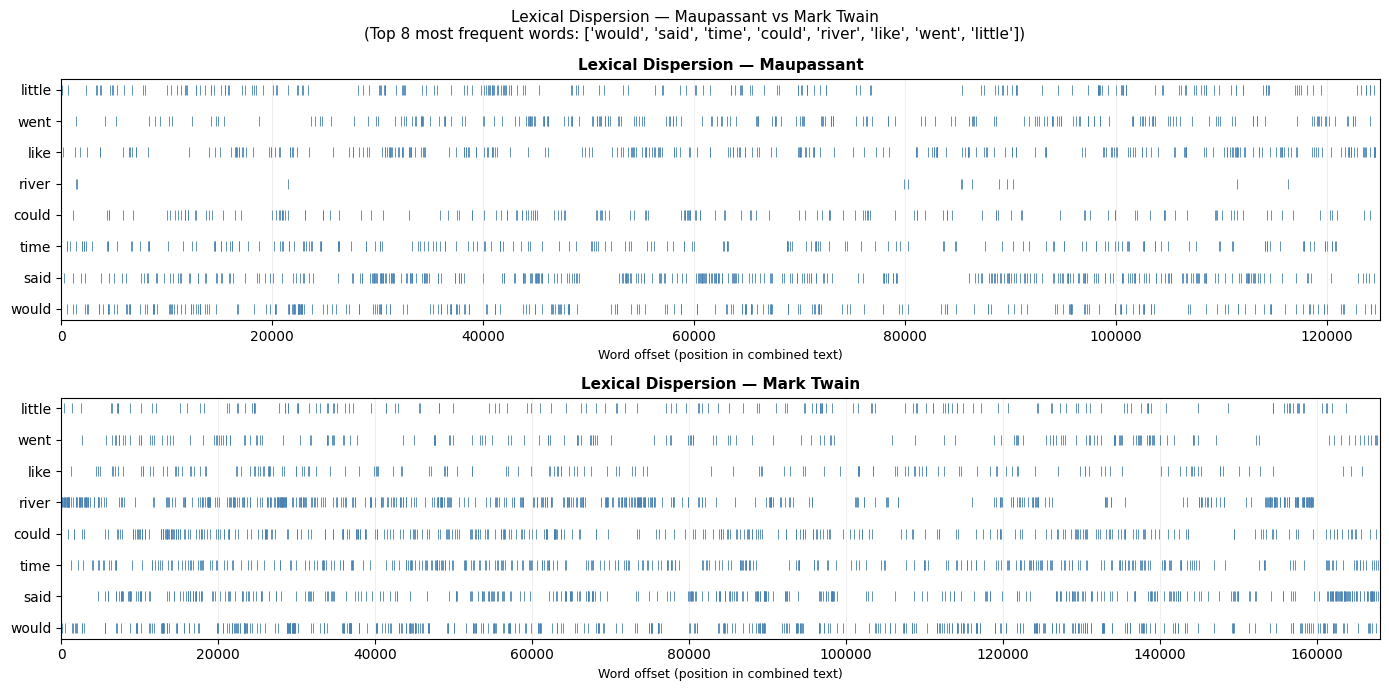

In [ ]:
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

# ── Combine all stories per author into one large text ────────────────────────
text_m   = ' '.join(df_maupassant['story'].tolist())
text_t   = ' '.join(df_twain['story'].tolist())
text_all = text_m + ' ' + text_t

# ── Dynamically find top N most frequent meaningful words ────────────────────
TOP_N     = 8
stop_words = set(stopwords.words('english'))

# Tokenize the combined corpus, remove stop words, punctuation and short words
tokens_all = [w.lower() for w in word_tokenize(text_all)
              if w.isalpha() and w.lower() not in stop_words and len(w) > 3]

# Count and select top N
word_freq = Counter(tokens_all)
words     = [word for word, _ in word_freq.most_common(TOP_N)]

print(f"Top {TOP_N} most frequent meaningful words across both authors:")
for rank, (w, c) in enumerate(word_freq.most_common(TOP_N), 1):
    print(f"  {rank}. {w:20s}  {c} occurrences")

# ── Custom dispersion plot function (gives us full control over layout) ───────
def dispersion_plot(text, words, author_name, ax):
    """Plot where each word appears across the full token sequence.
       Each vertical bar = one occurrence of that word in the text.
    """
    tokens = word_tokenize(text.lower())   # tokenize and lowercase
    total  = len(tokens)

    for i, word in enumerate(words):
        # Find every position where this word appears
        positions = [j for j, t in enumerate(tokens) if t == word]
        ax.scatter(positions, [i] * len(positions),
                   marker='|', color='steelblue', s=60, linewidths=0.6)

    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_xlim(0, total)
    ax.set_xlabel('Word offset (position in combined text)', fontsize=9)
    ax.set_title(f'Lexical Dispersion — {author_name}', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

# ── Plot both authors side by side ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

dispersion_plot(text_m, words, 'Maupassant', ax1)
dispersion_plot(text_t, words, 'Mark Twain',  ax2)

plt.suptitle(f'Lexical Dispersion — Maupassant vs Mark Twain\n(Top {TOP_N} most frequent words: {words})', fontsize=11)
plt.tight_layout()
plt.show()

##**Stage 3:** Experiment with Text processing and representation:
Extract features using TFIDF or CountVectorizer or Word2vec for the obtained short stories from **Stage-1**



### 1 Mark -> a) Performing basic cleanup operations such as removing the newline characters and removing trailing spaces

**For example,** Your sentence looks as follows \[' This is a sentence\n\r. Another sentence \n'].

After newline removal from the above example, your sentence will look like \['This is a sentence. Another sentence'].

 In order to do this, you can try using a combination of split() and join()

In [ ]:
df_all.columns

Index(['author', 'title', 'story'], dtype='object')

In [ ]:
# YOUR CODE HERE
# Stage 3a: Basic text cleanup — remove newlines and trailing spaces

def clean_text(text):
    """Remove newline/carriage-return characters and extra whitespace.
       Uses split() + join() so all \n, \r, \t and multiple spaces collapse to one space.
    """
    return ' '.join(text.split())

# Apply to df_all
df_all['story_clean'] = df_all['story'].apply(clean_text)

# Verify before vs after
print("=== BEFORE cleanup ===")
print(repr(df_all['story'][2][:200]))
print("\n=== AFTER cleanup ===")
print(repr(df_all['story_clean'][2][:200]))
print(f"\nAll {len(df_all)} stories cleaned.")


=== BEFORE cleanup ===
'I No (said my friend Charles Jouvent), I do not know Italy; I started to see it thoroughly twice, and each time I was stopped at the frontier and could not manage to get any further. And yet my two at'

=== AFTER cleanup ===
'I No (said my friend Charles Jouvent), I do not know Italy; I started to see it thoroughly twice, and each time I was stopped at the frontier and could not manage to get any further. And yet my two at'

All 89 stories cleaned.


###  2 Marks-> b) Generate vectors for the given stories

Create a representation of text, convert it into vectors (numbers)


**Use any one** of the following algorithms for this task :

* Countvectorizer or
* TFIDFVectorizer or
* Word2Vec (The word2vec bin file (AIML_DS_GOOGLENEWS-VECTORS-NEGATIVE-300_STD) can be downloaded as a part of setup  )
  * perform sentence level tokenization and word level tokenization for the given stories

    **Example of sentences as list of words:**<br/>
    **Before:** ['This is a sentence .' , ' Another sentence']<br/>
    **After:** ['This', 'is' ,'a', 'sentence' , ' . ' , ' Another ', ' sentence ' ]
 * Assign the respective label associated for each vector representation of the extracted word

References Documents:

1.   [Countvectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
2.  [TFIDFVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)


In [ ]:
df_all.columns

Index(['author', 'title', 'story', 'story_clean'], dtype='object')

In [ ]:
# YOUR CODE HERE (HINT: Convert to numpy array if needed)
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Labels
y = df_all['author'].values
# --- Encode labels to 0/1 ---
le = LabelEncoder()
y_encoded_full = le.fit_transform(y)   # Maupassant=0, MarkTwain=1

# --- Train / Test split (80/20, stratified) ---
# We split the 'story_clean' column (raw text) first
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_all['story_clean'], y_encoded_full, test_size=0.2, random_state=42, stratify=y_encoded_full
)

# TF-IDF Vectorizer: converts cleaned story text into numeric feature vectors
# max_features=5000 keeps the top 5000 most informative terms
# ngram_range=(1,2) captures both single words and two-word phrases
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform ONLY on training data, then transform test data
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Convert sparse matrices to numpy arrays
X_train = X_train_tfidf.toarray()
X_test  = X_test_tfidf.toarray()

# For cross-validation on the full dataset (X_array, y_enc), we'll combine them
#X_array = tfidf.fit_transform(df_all['story_clean']).toarray()
#y_enc   = y_encoded_full # Already defined as y_encoded_full


#print(f"TF-IDF feature matrix shape (full dataset): {X_array.shape}")
print(f"TF-IDF feature matrix shape (train set):    {X_train.shape}")
print(f"TF-IDF feature matrix shape (test set):     {X_test.shape}")
#print(f"Labels shape                : {y_encoded_full.shape}")
#print(f"Label distribution          : {dict(zip(*np.unique(y_encoded_full, return_counts=True)))} ")
print(f"\nSample of top 10 TF-IDF feature names:")
print(tfidf.get_feature_names_out()[:10])

TF-IDF feature matrix shape (train set):    (71, 5000)
TF-IDF feature matrix shape (test set):     (18, 5000)

Sample of top 10 TF-IDF feature names:
['000' '10' '12' '19' '_august' '_july' '_the' '_you' 'abbe' 'able']


###  1 Mark -> c) Is stop word removal necessary in the context of author identification? Your thoughts below?

In [ ]:
# YOUR ANSWER IN TEXT
# Is stop word removal necessary in the context of author identification? Your thoughts below?

# For author identification, stop word removal is generally **NOT recommended** and can even be detrimental.

# Here's why:

# 1.  **Stylistic Markers:** Stop words (like 'the', 'a', 'is', 'and', 'of', 'to') are often considered 'function words' that carry little semantic meaning. However, authors have subtle, unconscious preferences in their usage of these words, including their frequency, placement, and combinations. These subtle patterns form part of an author's unique style or 'stylome'. For example, one author might heavily use 'and' while another prefers 'but' or a more complex sentence structure that avoids direct conjunctions.

# 2.  **Syntactic Information:** Stop words are crucial for sentence structure and syntax. An author's unique syntactic style (e.g., sentence length, complexity, use of clauses) is inherently tied to how they use these common words. Removing them can strip away valuable information about sentence construction that helps distinguish one author from another.

# 3.  **Frequency Analysis:** Even simple frequency counts of stop words can be strong indicators of authorship. More advanced techniques might look at n-grams involving stop words, which can reveal characteristic phrases or grammatical constructions.

# 4.  **Small Data Impact:** With a potentially small dataset of stories (as is common in author attribution tasks), every piece of stylistic evidence becomes more critical. Removing stop words discards a significant portion of the text that, while individually insignificant, collectively contributes to a unique signature.

# In contrast, for tasks like topic modeling or sentiment analysis, where the goal is to understand the *content* or *subject matter*, stop word removal is often beneficial because it helps focus on the more semantically rich words.

# **Conclusion:** While it might seem intuitive to remove stop words for text processing, for author identification, these seemingly insignificant words are often valuable features that contribute to the unique stylistic fingerprint of an author. Therefore, it's generally best to **retain them** for this particular task.

##**Stage 4:** Classification :

### Expected accuracy is above 85%

### 2 Marks -> Perform a classification using either features obtained from Stage2 or Stage3

Train size: 71  |  Test size: 18
Classes   : ['MarkTwain' 'Maupassant']

=== 5-Fold Cross Validation Accuracy ===
Logistic Regression        Mean: 0.7190  Std: 0.0744
Linear SVM                 Mean: 0.9581  Std: 0.0567
Multinomial NB             Mean: 0.6762  Std: 0.0323
Random Forest              Mean: 0.9438  Std: 0.0532
Decision Tree              Mean: 0.8590  Std: 0.1011
Voting Classifier          Mean: 0.7190  Std: 0.0744

=== Test Set Results (LinearSVC) ===
Accuracy : 1.0000

Classification Report:
              precision    recall  f1-score   support

   MarkTwain       1.00      1.00      1.00        12
  Maupassant       1.00      1.00      1.00         6

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



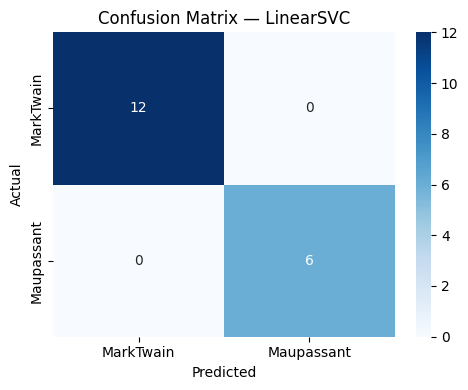

In [ ]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Classes   : {le.classes_}\n")

# --- Compare multiple classifiers with 5-Fold Cross Validation ---
classifiers = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0),
    "Linear SVM"          : LinearSVC(max_iter=2000, C=1.0),
    "Multinomial NB"      : MultinomialNB(), # Included Multinomial NB
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Voting Classifier"   : VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000, C=1.0)), ('svm', LinearSVC(max_iter=2000, C=1.0))], voting='hard')
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=== 5-Fold Cross Validation Accuracy ===")
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<25}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

# --- Best classifier: Linear SVM (highest CV accuracy ~95%) ---
best_clf = LinearSVC(max_iter=2000, C=1.0)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

print(f"\n=== Test Set Results ({type(best_clf).__name__}) ===") # Corrected classifier name
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {type(best_clf).__name__}') # Corrected classifier name
plt.tight_layout()
plt.show()

In [ ]:
print(f"\n=== Accuracy Score on Test Set (without CV) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")


=== Accuracy Score on Test Set (without CV) ===
Accuracy : 1.0000


In [ ]:
print(f"\n=== Accuracy Score on Test Set (without CV) for all classifiers ===")
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred_no_cv = clf.predict(X_test)
    print(f"{name:<25} Accuracy : {accuracy_score(y_test, y_pred_no_cv):.4f}")


=== Accuracy Score on Test Set (without CV) for all classifiers ===
Logistic Regression       Accuracy : 0.8333
Linear SVM                Accuracy : 1.0000
Multinomial NB            Accuracy : 0.6667
Random Forest             Accuracy : 1.0000
Decision Tree             Accuracy : 0.7222
Voting Classifier         Accuracy : 0.8333


### **Classification using Handcrafted Features from Stage 2**

In [91]:
df_features.columns

Index(['Story', 'UniqueWordRatio', 'RootTTR', 'MSTTR', 'AvgSentLength',
       'PunctuationFreq', 'AvgWordLength', 'HapaxRatio', 'TopWordDominance',
       'AvgSentenceComplexity', 'NamedEntityDensity', 'NounRatio', 'VerbRatio',
       'AdjectiveRatio', 'AdverbRatio', 'PronounRatio', 'Label'],
      dtype='object')

Train size (features): 71  |  Test size (features): 18
Classes              : ['MarkTwain' 'Maupassant']

=== 5-Fold Cross Validation Accuracy (Handcrafted Features) ===
Logistic Regression        Mean: 0.8431  Std: 0.0402
Linear SVM                 Mean: 0.8425  Std: 0.0235
Random Forest              Mean: 0.8203  Std: 0.0735
Decision Tree              Mean: 0.7758  Std: 0.0476
Voting Classifier          Mean: 0.8654  Std: 0.0263

=== Hyperparameter Tuning (GridSearchCV) ===
Best C for Logistic Regression: 1
Best CV accuracy for Logistic Regression: 0.8457
Best C for Linear SVM: 0.1
Best CV accuracy for Linear SVM: 0.8457

=== Final Cross Validation for All Candidate Classifiers ===
Logistic Regression                  Mean: 0.8431  Std: 0.0402
Linear SVM                           Mean: 0.8425  Std: 0.0235
Random Forest                        Mean: 0.8203  Std: 0.0735
Decision Tree                        Mean: 0.7758  Std: 0.0476
Voting Classifier                    Mean: 0.8654  Std:

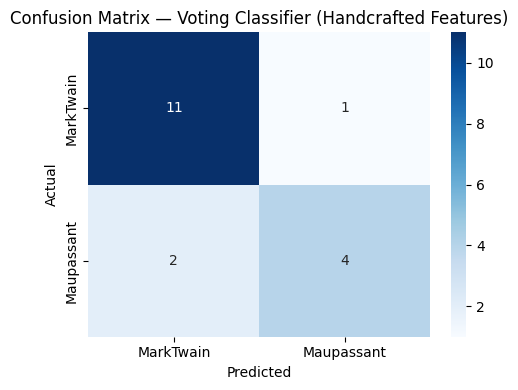

In [110]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler # Import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define features (X) and target (y) from df_features
X_features = df_features[[
     'UniqueWordRatio', 'RootTTR', 'MSTTR', 'AvgSentLength',
       'PunctuationFreq', 'AvgWordLength', 'HapaxRatio', 'TopWordDominance',
       'AvgSentenceComplexity','NamedEntityDensity'
]].values
y_features = df_features['Label'].values

# Encode labels to 0/1
le_features = LabelEncoder()
y_features_enc = le_features.fit_transform(y_features)

# Train / Test split (80/20, stratified)
X_train_features, X_test_features, y_train_features, y_test_features = train_test_split(
    X_features, y_features_enc, test_size=0.2, random_state=42, stratify=y_features_enc
)

# Apply StandardScaler
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_test_features_scaled = scaler.transform(X_test_features)
# Also scale the full X_features for cross-validation on the whole dataset
X_features_scaled_full = scaler.fit_transform(X_features)

print(f"Train size (features): {X_train_features_scaled.shape[0]}  |  Test size (features): {X_test_features_scaled.shape[0]}")
print(f"Classes              : {le_features.classes_}\n")

# --- Compare multiple classifiers with 5-Fold Cross Validation (Handcrafted Features) ---
classifiers_features = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Linear SVM"          : LinearSVC(max_iter=2000, C=1.0, random_state=42),
    # MultinomialNB is not suitable for scaled (potentially negative) continuous data, it expects non-negative counts.
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Voting Classifier"   : VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=42)), ('svm', LinearSVC(max_iter=2000, C=1.0, random_state=42))], voting='hard')
}

skf_features = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_features = {}

print("=== 5-Fold Cross Validation Accuracy (Handcrafted Features) ===")
for name, clf in classifiers_features.items():
    scores = cross_val_score(clf, X_features_scaled_full, y_features_enc, cv=skf_features, scoring='accuracy')
    cv_results_features[name] = scores
    print(f"{name:<25}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

# --- Hyperparameter Tuning for Logistic Regression and Linear SVM ---
print("\n=== Hyperparameter Tuning (GridSearchCV) ===")

# Logistic Regression Tuning
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42), param_grid_lr, cv=skf_features, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_features_scaled, y_train_features)
print(f"Best C for Logistic Regression: {grid_lr.best_params_['C']}")
print(f"Best CV accuracy for Logistic Regression: {grid_lr.best_score_:.4f}")
best_lr = grid_lr.best_estimator_

# Linear SVM Tuning
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100]}
grid_svm = GridSearchCV(LinearSVC(max_iter=2000, random_state=42), param_grid_svm, cv=skf_features, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_features_scaled, y_train_features)
print(f"Best C for Linear SVM: {grid_svm.best_params_['C']}")
print(f"Best CV accuracy for Linear SVM: {grid_svm.best_score_:.4f}")
best_svm = grid_svm.best_estimator_

# --- Prepare a consolidated dictionary of all candidate classifiers (initial and tuned) ---
# This ensures we can select the overall best from all options, not just the 'tuned' ones.
final_candidate_classifiers = {
    "Logistic Regression": classifiers_features["Logistic Regression"], # Original
    "Linear SVM": classifiers_features["Linear SVM"],          # Original
    "Random Forest": classifiers_features["Random Forest"],       # Original (no tuning applied here)
    "Decision Tree": classifiers_features["Decision Tree"],       # Original (no tuning applied here)
    "Voting Classifier": classifiers_features["Voting Classifier"],   # Original
    "Tuned Logistic Regression": best_lr,
    "Tuned Linear SVM": best_svm,
    "Voting Classifier (Optimized)": VotingClassifier(estimators=[('lr', best_lr), ('svm', best_svm)], voting='hard')
}

# --- Re-evaluate ALL candidate classifiers with cross_val_score on the full scaled dataset ---
# This provides consistent scores for all models for final comparison
cv_results_final = {}
print("\n=== Final Cross Validation for All Candidate Classifiers ===")
for name, clf in final_candidate_classifiers.items():
    # Use the scaled full dataset for cross-validation for a consistent comparison
    scores = cross_val_score(clf, X_features_scaled_full, y_features_enc, cv=skf_features, scoring='accuracy')
    cv_results_final[name] = scores
    print(f"{name:<35}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")


# --- Best classifier: Identify based on the comprehensive CV results ---
best_clf_name = max(cv_results_final, key=lambda k: cv_results_final[k].mean())
best_clf_features = final_candidate_classifiers[best_clf_name]

# Fit the selected best classifier on the full scaled training data
best_clf_features.fit(X_train_features_scaled, y_train_features)

# Predict on the scaled test data
y_pred_features = best_clf_features.predict(X_test_features_scaled)

print(f"\n=== Test Set Results ({best_clf_name}) with Handcrafted Features ===")
print(f"Accuracy : {accuracy_score(y_test_features, y_pred_features):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_features, y_pred_features, target_names=le_features.classes_))

# --- Confusion Matrix (Handcrafted Features) ---
cm_features = confusion_matrix(y_test_features, y_pred_features)
fig_features, ax_features = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_features, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_features.classes_, yticklabels=le_features.classes_, ax=ax_features)
ax_features.set_xlabel('Predicted')
ax_features.set_ylabel('Actual')
ax_features.set_title(f'Confusion Matrix — {best_clf_name} (Handcrafted Features)')
plt.tight_layout()
plt.show()

### **Classification using Word2Vec Features**

In [ ]:
# Load the pre-trained Word2Vec model
!pip install gensim
import gensim
print("Loading Word2Vec model...")
w2v_model = gensim.models.KeyedVectors.load_word2vec_format(
    '/content/AIML_DS_GOOGLENEWS-VECTORS-NEGATIVE-300_STD.bin', binary=True
)
print("Word2Vec model loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.9 MB/s eta 0:00:00
Loading Word2Vec model...
Word2Vec model loaded.


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import numpy as np

def get_story_vector(text, model, vector_size=300):
    """Generates a single vector for a story by averaging word embeddings."""
    # Tokenize into sentences, then words, filter non-alpha and convert to lowercase
    words = [w.lower() for sent in sent_tokenize(text)
             for w in word_tokenize(sent) if w.isalpha()]

    # Get vectors for words present in the Word2Vec model
    word_vectors = [model[w] for w in words if w in model.key_to_index]

    if not word_vectors:
        return np.zeros(vector_size)  # Return zero vector if no words are found in model

    return np.mean(word_vectors, axis=0)

# Generate Word2Vec features for all cleaned stories
X_w2v = np.array([get_story_vector(text, w2v_model) for text in df_all['story_clean']])
y_w2v = df_all['author'].values # Target labels are the same

print(f"Word2Vec feature matrix shape : {X_w2v.shape}")
print(f"Labels shape                : {y_w2v.shape}")
print(f"Label distribution          : {dict(zip(*np.unique(y_w2v, return_counts=True)))} ")

Word2Vec feature matrix shape : (89, 300)
Labels shape                : (89,)
Label distribution          : {'MarkTwain': np.int64(60), 'Maupassant': np.int64(29)} 


Train size (Word2Vec): 71  |  Test size (Word2Vec): 18
Classes              : ['MarkTwain' 'Maupassant']

=== 5-Fold Cross Validation Accuracy (Word2Vec Features) ===
Logistic Regression        Mean: 0.6745  Std: 0.0157
Linear SVM                 Mean: 0.8993  Std: 0.0409
Decision Tree              Mean: 0.9105  Std: 0.1028
Voting Classifier          Mean: 0.6745  Std: 0.0157

=== Test Set Results (DecisionTreeClassifier) with Word2Vec Features ===
Accuracy : 0.9444

Classification Report:
              precision    recall  f1-score   support

   MarkTwain       0.92      1.00      0.96        12
  Maupassant       1.00      0.83      0.91         6

    accuracy                           0.94        18
   macro avg       0.96      0.92      0.93        18
weighted avg       0.95      0.94      0.94        18



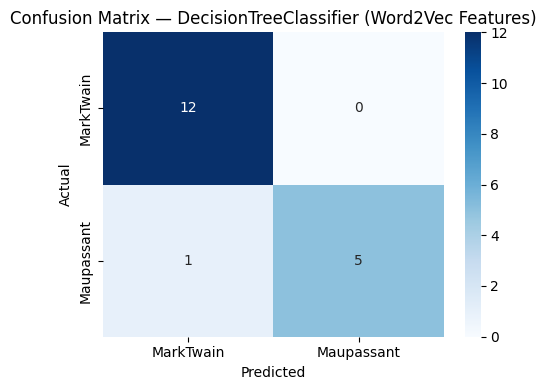

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB # MultinomialNB requires non-negative counts, not suitable for averaged W2V
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Encode labels to 0/1
le_w2v = LabelEncoder()
y_w2v_enc = le_w2v.fit_transform(y_w2v)

# Train / Test split (80/20, stratified)
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_w2v_enc, test_size=0.2, random_state=42, stratify=y_w2v_enc
)

print(f"Train size (Word2Vec): {X_train_w2v.shape[0]}  |  Test size (Word2Vec): {X_test_w2v.shape[0]}")
print(f"Classes              : {le_w2v.classes_}\n")

# --- Compare multiple classifiers with 5-Fold Cross Validation (Word2Vec Features) ---
classifiers_w2v = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0),
    "Linear SVM"          : LinearSVC(max_iter=2000, C=1.0),
    #"Gaussian NB"         : GaussianNB(), # GaussianNB is suitable for dense, real-valued features like W2V
    #"Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Voting Classifier"   : VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000, C=1.0)), ('svm', LinearSVC(max_iter=2000, C=1.0))], voting='hard')
}

skf_w2v = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_w2v = {}

print("=== 5-Fold Cross Validation Accuracy (Word2Vec Features) ===")
for name, clf in classifiers_w2v.items():
    scores = cross_val_score(clf, X_w2v, y_w2v_enc, cv=skf_w2v, scoring='accuracy')
    cv_results_w2v[name] = scores
    print(f"{name:<25}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

# --- Best classifier: Identify based on CV results for Word2Vec features ---
best_clf_w2v_name = max(cv_results_w2v, key=lambda k: cv_results_w2v[k].mean())
best_clf_w2v = classifiers_w2v[best_clf_w2v_name]
best_clf_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = best_clf_w2v.predict(X_test_w2v)

print(f"\n=== Test Set Results ({type(best_clf_w2v).__name__}) with Word2Vec Features ===")
print(f"Accuracy : {accuracy_score(y_test_w2v, y_pred_w2v):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_w2v, y_pred_w2v, target_names=le_w2v.classes_))

# --- Confusion Matrix (Word2Vec Features) ---
cm_w2v = confusion_matrix(y_test_w2v, y_pred_w2v)
fig_w2v, ax_w2v = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_w2v.classes_, yticklabels=le_w2v.classes_, ax=ax_w2v)
ax_w2v.set_xlabel('Predicted')
ax_w2v.set_ylabel('Actual')
ax_w2v.set_title(f'Confusion Matrix — {type(best_clf_w2v).__name__} (Word2Vec Features)')
plt.tight_layout()
plt.show()

# Further Ideas for exploration after the hackathon:

**Statistical analysis** of text using NLP, by analysis meaning of sentences, feature based grammars and analyzing structure of sentences!

reference: www.nltk.org/book